In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class AgentState(TypedDict):
    number1: int
    number2: int
    operation1: str
    final_number1: int

    number3: int
    number4: int
    operation2: str
    final_number2: int

def adder1(state: AgentState) -> AgentState:
    """Node responsible for performing addition operation"""
    state['final_number1'] = state['number1'] + state['number2']
    return state

def subtractor1(state: AgentState) -> AgentState:
    """Node responsible for performing subtraction operation"""
    state['final_number1'] = state['number1'] - state['number2']
    return state

def decide_next_node1(state: AgentState) -> str:
    """Node responsible for deciding the next operation based on the state"""

    if state['operation1'] == '+':
        return 'adder1'
    elif state['operation1'] == '-':
        return 'subtractor1'
    
def adder2(state: AgentState) -> AgentState:
    """Node responsible for performing addition operation"""
    state['final_number2'] = state['number3'] + state['number4']
    return state

def subtractor2(state: AgentState) -> AgentState:
    """Node responsible for performing subtraction operation"""
    state['final_number2'] = state['number3'] - state['number4']
    return state

def decide_next_node2(state: AgentState) -> str:
    """Node responsible for deciding the next operation based on the state"""

    if state['operation2'] == '+':
        return 'adder2'
    elif state['operation2'] == '-':
        return 'subtractor2'

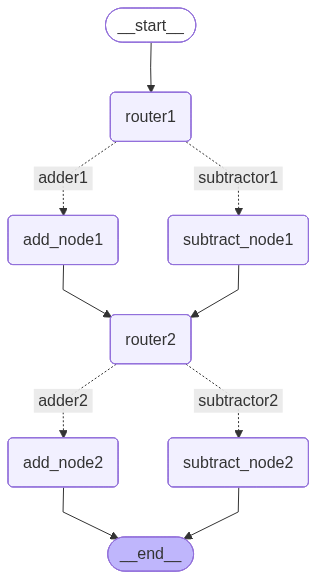

{'number1': 10,
 'number2': 2,
 'operation1': '+',
 'final_number1': 12,
 'number3': 20,
 'number4': 15,
 'operation2': '-',
 'final_number2': 5}

In [17]:
graph = StateGraph(AgentState)
graph.add_node("add_node1", adder1)
graph.add_node("subtract_node1", subtractor1)
graph.add_node("router1", lambda state: state)

graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)
graph.add_node("router2", lambda state: state)

graph.add_edge(START, "router1")

graph.add_conditional_edges(
    "router1",
    decide_next_node1,
    {'adder1': 'add_node1', 'subtractor1': 'subtract_node1'}
)
graph.add_edge("add_node1", "router2")
graph.add_edge("subtract_node1", "router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {'adder2': 'add_node2', 'subtractor2': 'subtract_node2'}
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

state = AgentState(
    number1=10,
    number2=2,
    operation1='+',
    final_number1=0,
    number3=20,
    number4=15,
    operation2='-',
    final_number2=0
)

result = app.invoke(state)
result